# Trader Performance vs. Bitcoin Market Sentiment

Reproducible analysis notebook joining Hyperliquid historical trade data with the Bitcoin Fear & Greed Index.

**Inputs** (place alongside this notebook, or edit the paths below):
- `historical_data.csv` — Hyperliquid trade log
- `fear_greed_index.csv` — Bitcoin Fear & Greed Index

**Outputs:** merged dataset, summary tables, and charts used in the accompanying report.

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

HIST_PATH = "C:\\Users\\ADMIN\\Downloads\\historical_data.csv"
FG_PATH = "C:\\Users\\ADMIN\\Downloads\\fear_greed_index.csv"

## 2. Load & clean data

In [3]:
hd = pd.read_csv(HIST_PATH)
fg = pd.read_csv(FG_PATH)

hd["Datetime"] = pd.to_datetime(hd["Timestamp IST"], format="%d-%m-%Y %H:%M")
hd["Date"] = hd["Datetime"].dt.date
fg["date"] = pd.to_datetime(fg["date"]).dt.date

print("Trade rows:", hd.shape)
print("Sentiment rows:", fg.shape)
hd.head()

Trade rows: (211224, 18)
Sentiment rows: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Datetime,Date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02


## 3. Merge trades with daily sentiment

In [4]:
fg_small = fg[["date", "value", "classification"]].rename(
    columns={"date": "Date", "value": "SentimentValue", "classification": "Sentiment"}
)
merged = hd.merge(fg_small, on="Date", how="left").dropna(subset=["Sentiment"])

def bucket(s):
    if s in ["Fear", "Extreme Fear"]:
        return "Fear"
    if s in ["Greed", "Extreme Greed"]:
        return "Greed"
    return "Neutral"

merged["SentimentBucket"] = merged["Sentiment"].apply(bucket)
merged.to_csv("merged_trades_with_sentiment.csv", index=False)

print("Merged shape:", merged.shape)
merged[["Account","Coin","Closed PnL","Sentiment","SentimentBucket"]].head()

Merged shape: (211218, 21)


,Account,Coin,Closed PnL,Sentiment,SentimentBucket
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,Greed


## 4. Isolate realized (closing) trades. PnL is only realized when a position is closed, so we filter to trades with non-zero `Closed PnL`.

In [5]:
closes = merged[merged["Closed PnL"] != 0].copy()
closes["LongShort"] = closes["Direction"].apply(
    lambda d: "Long" if "Long" in str(d) else ("Short" if "Short" in str(d) else "Spot/Other")
)
closes["pnl_pct"] = closes["Closed PnL"] / closes["Size USD"] * 100

print("Realized trades:", len(closes))
closes[["Coin","Direction","LongShort","Closed PnL","pnl_pct","SentimentBucket"]].head()

Realized trades: 104402


,Coin,Direction,LongShort,Closed PnL,pnl_pct,SentimentBucket
44,@107,Sell,Spot/Other,3008.231185,13.576919,Greed
45,@107,Sell,Spot/Other,30.741534,13.576617,Greed
46,@107,Sell,Spot/Other,40.770089,13.491095,Greed
47,@107,Sell,Spot/Other,243.812267,13.475651,Greed
48,@107,Sell,Spot/Other,254.263735,13.437395,Greed


## 5. Summary tables by sentiment

In [6]:
def summarize(df, col):
    return df.groupby(col).agg(
        trades=("Closed PnL", "count"),
        total_pnl=("Closed PnL", "sum"),
        avg_pnl=("Closed PnL", "mean"),
        median_pnl=("Closed PnL", "median"),
        win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100),
        avg_size_usd=("Size USD", "mean"),
        total_fee=("Fee", "sum"),
    ).round(2)

summary_5level = summarize(closes, "Sentiment")
summary_3bucket = summarize(closes, "SentimentBucket")

summary_5level.to_csv("summary_5level.csv")
summary_3bucket.to_csv("summary_3bucket.csv")

display(summary_5level)
display(summary_3bucket)

,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_size_usd,total_fee
Sentiment,,,,,,,
Extreme Fear,10406,739110.25,71.03,6.39,76.22,5467.57,12230.24
Extreme Greed,20853,2715171.31,130.21,8.53,89.17,2779.56,13665.86
Fear,29808,3357155.44,112.63,6.35,87.29,8041.14,46999.22
Greed,25176,2150129.27,85.40,4.93,76.89,5438.67,29677.69
Neutral,18159,1292920.68,71.20,4.58,82.39,5556.44,22262.69


,trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_size_usd,total_fee
SentimentBucket,,,,,,,
Fear,40214,4096265.69,101.86,6.36,84.42,7375.19,59229.46
Greed,46029,4865300.58,105.70,6.49,82.45,4233.99,43343.55
Neutral,18159,1292920.68,71.20,4.58,82.39,5556.44,22262.69


## 6. Statistical test: Fear vs. Greed average PnL

In [7]:
fear_pnl = closes.loc[closes.SentimentBucket == "Fear", "Closed PnL"]
greed_pnl = closes.loc[closes.SentimentBucket == "Greed", "Closed PnL"]

t, p = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
print(f"Welch's t-test  ->  t = {t:.3f},  p = {p:.4f}")

mw, pmw = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")
print(f"Mann-Whitney U  ->  U = {mw:.1f}, p = {pmw:.4f}")

Welch's t-test  ->  t = -0.403,  p = 0.6873
Mann-Whitney U  ->  U = 923210585.0, p = 0.5293


## 7. Risk-adjusted performance (return on notional)

In [8]:
riskadj = closes.groupby("SentimentBucket")["pnl_pct"].agg(["mean", "std"])
riskadj["sharpe_like"] = riskadj["mean"] / riskadj["std"]
riskadj

,mean,std,sharpe_like
SentimentBucket,,,
Fear,2.599436,11.281581,0.230414
Greed,5.623685,180.104079,0.031225
Neutral,2.062014,25.245959,0.081677


## 8. Long vs. Short performance by sentiment

In [9]:
ls = closes.groupby(["SentimentBucket", "LongShort"]).agg(
    trades=("Closed PnL", "count"),
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100),
)
ls

trades     avg_pnl   win_rate
SentimentBucket LongShort                                
Fear            Long         23544   82.734471  88.485389
                Short        12329  186.521616  82.285668
                Spot/Other    4341  -34.844436  68.463488
Greed           Long         15204   76.260123  87.654565
                Short        17809   44.943105  75.096861
                Spot/Other   13016  223.221413  86.439766
Neutral         Long         10012   52.772154  86.176588
                Short         5849   94.812521  77.671397
                Spot/Other    2298   91.387050  77.893821

## 9. Daily aggregation & correlation with the sentiment index

In [10]:
daily = closes.groupby("Date").agg(
    total_pnl=("Closed PnL", "sum"),
    trades=("Closed PnL", "count"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100),
    avg_size=("Size USD", "mean"),
    sentiment_value=("SentimentValue", "first"),
).reset_index()
daily.to_csv("daily_agg.csv", index=False)

print("Corr(sentiment, daily PnL):      ", round(daily["sentiment_value"].corr(daily["total_pnl"]), 3))
print("Corr(sentiment, daily win rate): ", round(daily["sentiment_value"].corr(daily["win_rate"]), 3))
print("Corr(sentiment, avg trade size): ", round(daily["sentiment_value"].corr(daily["avg_size"]), 3))
print("Corr(sentiment, trade count):    ", round(daily["sentiment_value"].corr(daily["trades"]), 3))

Corr(sentiment, daily PnL):       -0.098
Corr(sentiment, daily win rate):  0.055
Corr(sentiment, avg trade size):  -0.083
Corr(sentiment, trade count):     -0.249


## 10. Asset-level winners & losers

In [11]:
coin_perf = closes.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False)
print("Top 10 coins by total PnL:")
display(coin_perf.head(10))
print("Bottom 10 coins by total PnL:")
display(coin_perf.tail(10))

Top 10 coins by total PnL:


Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

Bottom 10 coins by total PnL:


Coin
NIL          -3175.273635
@135         -5981.363990
POPCAT       -7922.181871
S            -8644.845718
KAITO        -8735.140961
PAXG        -18688.874329
IO          -21893.910518
ADA         -28113.461970
FARTCOIN   -100687.213185
TRUMP      -364824.908179
Name: Closed PnL, dtype: float64

## 11. Account-level winners & losers

In [12]:
acct_perf = closes.groupby("Account").agg(
    trades=("Closed PnL", "count"),
    total_pnl=("Closed PnL", "sum"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100),
).sort_values("total_pnl", ascending=False)

print("Top 5 accounts:")
display(acct_perf.head())
print("Bottom 5 accounts:")
display(acct_perf.tail())

Top 5 accounts:


,trades,total_pnl,win_rate
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6279,2.143383e+06,79.104953
0x083384f897ee0f19899168e3b1bec365f52a9012,1732,1.600230e+06,79.272517
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9997,9.401638e+05,99.119736
0x513b8629fe877bb581bf244e326a047b249c4ff1,5482,8.404226e+05,89.547610
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,22551,8.360806e+05,76.307037


Bottom 5 accounts:


,trades,total_pnl,win_rate
Account,,,
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,746,14900.443047,94.504021
0x39cef799f8b69da1995852eea189df24eb5cae3c,1767,14456.919336,66.553480
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,570,-31203.599986,65.087719
0x271b280974205ca63b716753467d5a371de622ab,1607,-70436.191318,71.561917
0x8170715b3b381dffb7062c0298972d4727a0a63b,2341,-167621.124781,75.224263


## 12. Charts

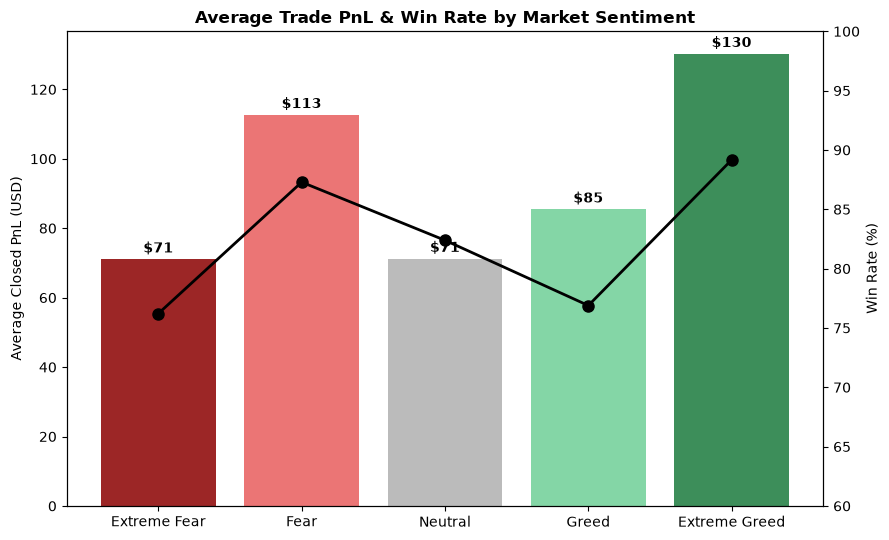

In [13]:
order5 = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
colors5 = ["#8B0000", "#E85D5D", "#B0B0B0", "#6FCF97", "#1B7A3D"]

g = closes.groupby("Sentiment").agg(
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100)
).reindex(order5)

fig, ax1 = plt.subplots(figsize=(9, 5.5))
bars = ax1.bar(order5, g["avg_pnl"], color=colors5, alpha=0.85)
ax1.set_ylabel("Average Closed PnL (USD)")
ax1.set_title("Average Trade PnL & Win Rate by Market Sentiment", fontweight="bold")
for b, v in zip(bars, g["avg_pnl"]):
    ax1.text(b.get_x() + b.get_width()/2, v + 2, f"${v:.0f}", ha="center", fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(order5, g["win_rate"], color="black", marker="o", linewidth=2, markersize=8)
ax2.set_ylabel("Win Rate (%)")
ax2.set_ylim(60, 100)
plt.tight_layout()
plt.savefig("chart1_pnl_winrate.png", dpi=150)
plt.show()

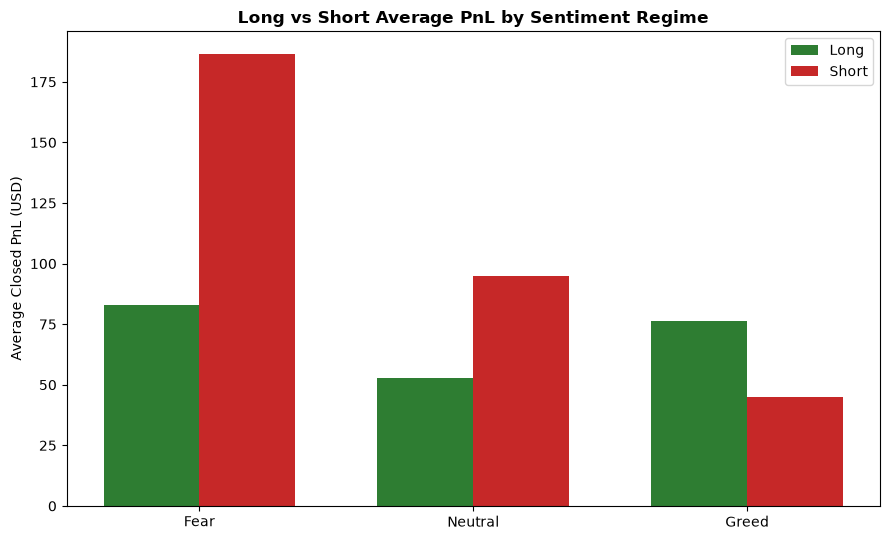

In [14]:
order3 = ["Fear", "Neutral", "Greed"]
piv = closes[closes["LongShort"].isin(["Long", "Short"])].groupby(
    ["SentimentBucket", "LongShort"]
)["Closed PnL"].mean().unstack().reindex(order3)

x = np.arange(len(order3))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - w/2, piv["Long"], w, label="Long", color="#2E7D32")
ax.bar(x + w/2, piv["Short"], w, label="Short", color="#C62828")
ax.set_xticks(x); ax.set_xticklabels(order3)
ax.set_ylabel("Average Closed PnL (USD)")
ax.set_title("Long vs Short Average PnL by Sentiment Regime", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("chart2_long_short.png", dpi=150)
plt.show()

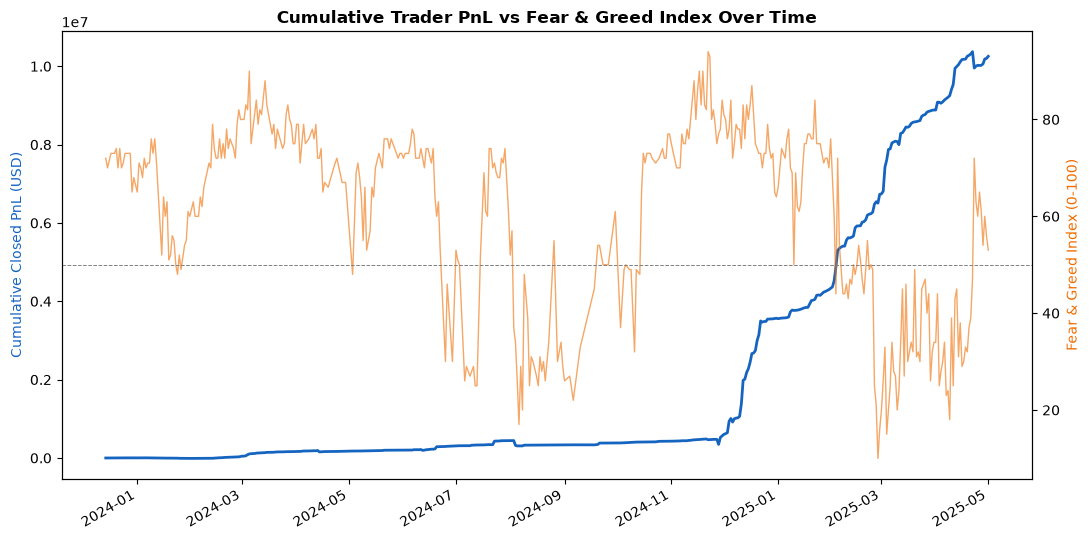

In [15]:
daily_sorted = daily.sort_values("Date").copy()
daily_sorted["cum_pnl"] = daily_sorted["total_pnl"].cumsum()

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.plot(daily_sorted["Date"], daily_sorted["cum_pnl"], color="#1565C0", linewidth=2)
ax1.set_ylabel("Cumulative Closed PnL (USD)", color="#1565C0")
ax1.set_title("Cumulative Trader PnL vs Fear & Greed Index Over Time", fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(daily_sorted["Date"], daily_sorted["sentiment_value"], color="#EF6C00", linewidth=1, alpha=0.6)
ax2.set_ylabel("Fear & Greed Index (0-100)", color="#EF6C00")
ax2.axhline(50, color="gray", linestyle="--", linewidth=0.7)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("chart3_cumpnl_sentiment.png", dpi=150)
plt.show()

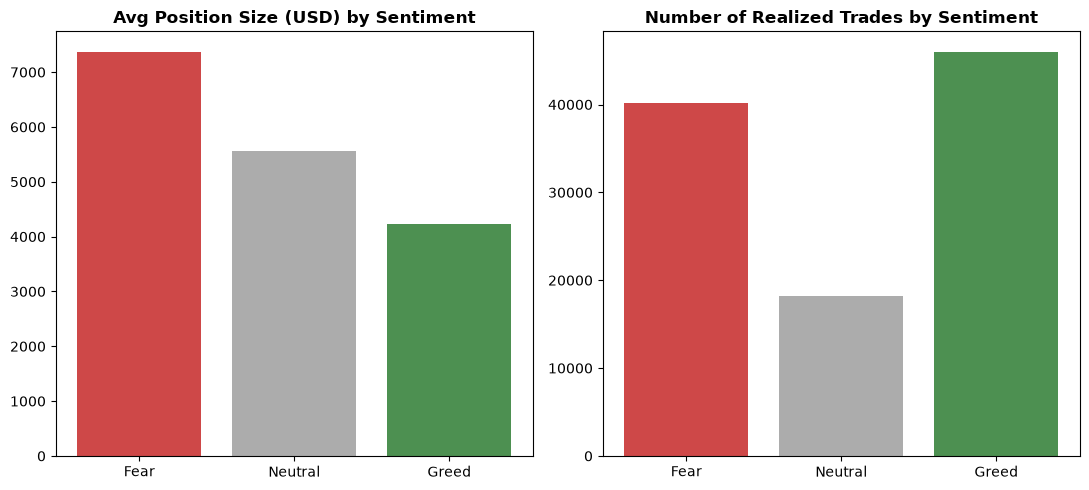

In [16]:
colors3 = ["#C62828", "#9E9E9E", "#2E7D32"]
g_size = closes.groupby("SentimentBucket")["Size USD"].mean().reindex(order3)
g_count = closes.groupby("SentimentBucket").size().reindex(order3)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(order3, g_size.values, color=colors3, alpha=0.85)
axes[0].set_title("Avg Position Size (USD) by Sentiment", fontweight="bold")
axes[1].bar(order3, g_count.values, color=colors3, alpha=0.85)
axes[1].set_title("Number of Realized Trades by Sentiment", fontweight="bold")
plt.tight_layout()
plt.savefig("chart4_size_activity.png", dpi=150)
plt.show()

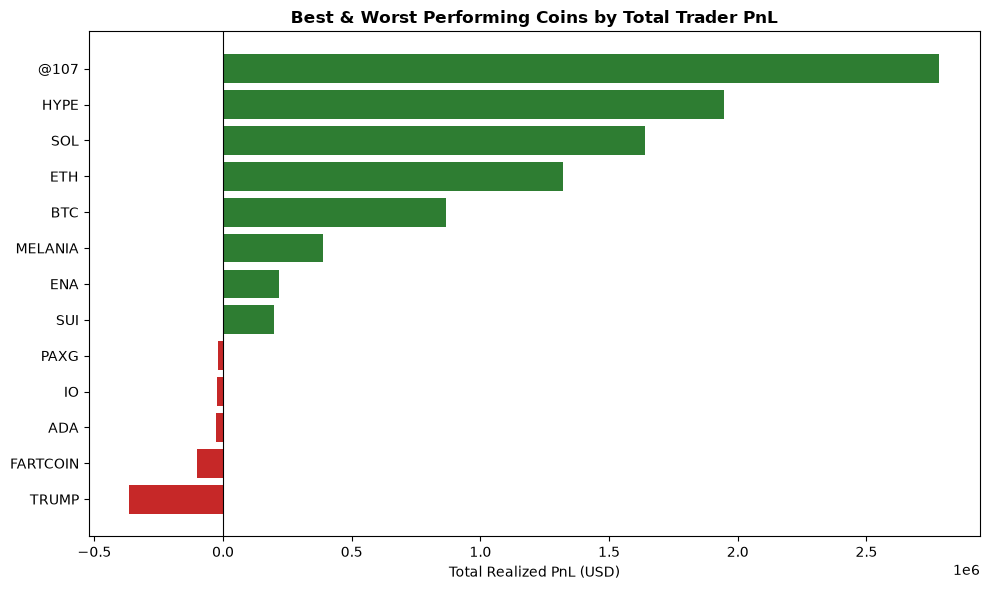

In [17]:
top10 = coin_perf.head(8)
bottom5 = coin_perf.tail(5)
combo = pd.concat([top10, bottom5])
colors = ["#2E7D32" if v >= 0 else "#C62828" for v in combo.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(combo.index[::-1], combo.values[::-1], color=colors[::-1])
ax.set_xlabel("Total Realized PnL (USD)")
ax.set_title("Best & Worst Performing Coins by Total Trader PnL", fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("chart5_coins.png", dpi=150)
plt.show()

## 13. Key takeaways

- Traders size up during Fear (avg **$7,375** position) vs. Greed (avg **$4,234**).
- Risk-adjusted returns strongly favor Fear — Greed-period returns are far more volatile (driven by rare extreme trades, including liquidation-scale losses).
- Shorts closed during Fear average **$186.52**/trade vs. **$82.73** for longs in the same regime — the strongest directional edge in the data.
- The sentiment index alone is a weak predictor of daily PnL (corr ≈ -0.10) but a useful risk-regime signal.
- A handful of tokens (TRUMP, FARTCOIN) drive outsized losses regardless of sentiment.

See the accompanying Word report for the full write-up and strategic implications.